In [1]:
import pandas as pd
import numpy as np

In [2]:
import os

data_path = r"C:\Users\BIT\Desktop\q\real_world_project_on_DL_sup_and_unsup\NEU-DET"

print(os.listdir(data_path))

['train', 'validation']


In [3]:
train_images_path = os.path.join(data_path, "train", "images")
validation_images_path = os.path.join(data_path, "validation", "images")

print("Train classes:")
print(os.listdir(train_images_path))

print("\nValidation classes:")
print(os.listdir(validation_images_path))

Train classes:
['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Validation classes:
['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [4]:
for class_name in sorted(os.listdir(train_images_path)):
    class_path = os.path.join(train_images_path, class_name)

    if os.path.isdir(class_path):
        print(class_name, ":", len(os.listdir(class_path)))

crazing : 240
inclusion : 240
patches : 240
pitted_surface : 240
rolled-in_scale : 240
scratches : 240


In [5]:
print("\nValidation:")

for class_name in sorted(os.listdir(validation_images_path)):
    class_path = os.path.join(validation_images_path, class_name)

    if os.path.isdir(class_path):
        print(class_name, ":", len(os.listdir(class_path)))


Validation:
crazing : 60
inclusion : 60
patches : 60
pitted_surface : 60
rolled-in_scale : 60
scratches : 60


In [6]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_images_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)


validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_images_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1440 files belonging to 6 classes.
Found 360 files belonging to 6 classes.


In [7]:
class_names = train_dataset.class_names

print(class_names)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


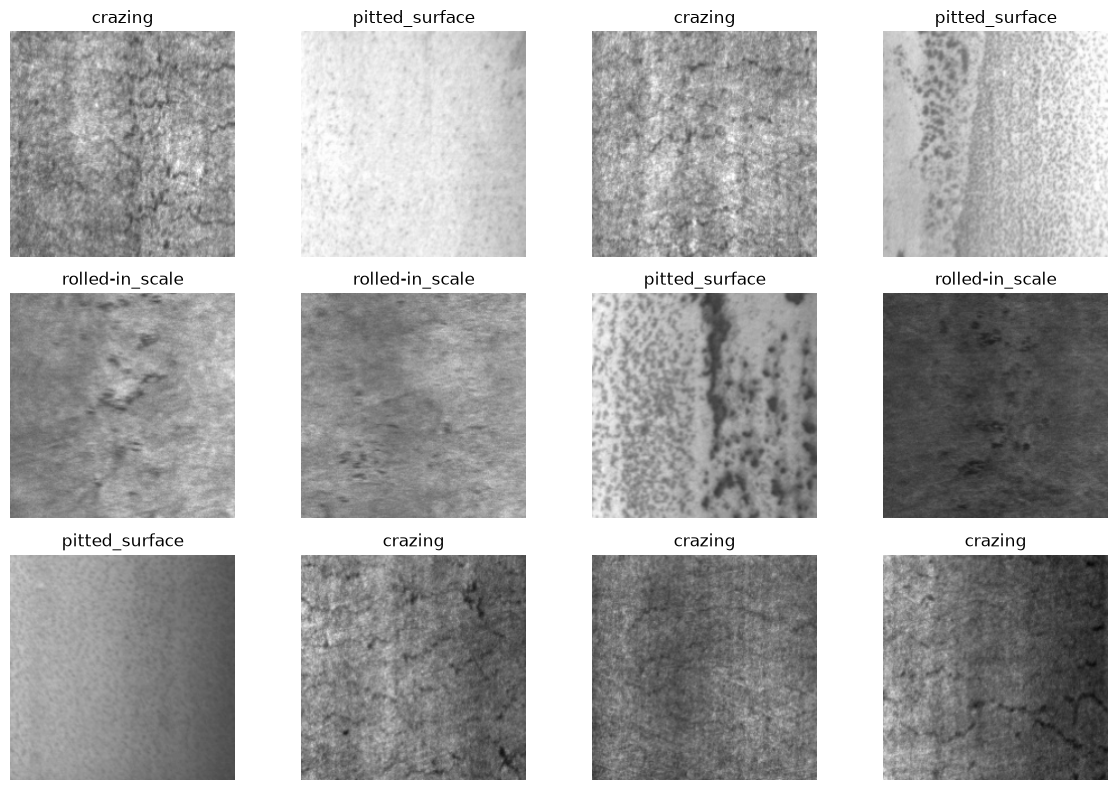

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):

    for i in range(12):

        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(train_dataset.class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

we have six classes. The images are grayscale, which makes sense for this steel-surface dataset.
Even though they're grayscale, TensorFlow will normally load them as:
(height, width, 3)
because image_dataset_from_directory() defaults to RGB.

In [9]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


How many images are there in each defect category?

In [10]:
import os

print("TRAIN DATASET")
print("=" * 40)

train_counts = {}

for class_name in sorted(os.listdir(train_images_path)):
    class_path = os.path.join(train_images_path, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        train_counts[class_name] = count
        print(f"{class_name:20s}: {count}")

TRAIN DATASET
crazing             : 240
inclusion           : 240
patches             : 240
pitted_surface      : 240
rolled-in_scale     : 240
scratches           : 240


In [11]:
print("\nVALIDATION DATASET")
print("=" * 40)

validation_counts = {}

for class_name in sorted(os.listdir(validation_images_path)):
    class_path = os.path.join(validation_images_path, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        validation_counts[class_name] = count
        print(f"{class_name:20s}: {count}")


VALIDATION DATASET
crazing             : 60
inclusion           : 60
patches             : 60
pitted_surface      : 60
rolled-in_scale     : 60
scratches           : 60


In [12]:
for images, labels in train_dataset.take(1):
    print("Batch shape:", images.shape)
    print("Single image shape:", images[0].shape)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Batch shape: (32, 224, 224, 3)
Single image shape: (224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 255.0


CNNs generally train more comfortably when inputs are scaled to approximately:

we will use:
Training set- 1224 Images (85%).
Validation Set - 216 (15%)   (Both from Training set)

Test set- 360 (Validations set as given in data)             

In [13]:
import tensorflow as tf
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_images_path = os.path.join(
    data_path, "train", "images"
)

test_images_path = os.path.join(
    data_path, "validation", "images"
)

In [14]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_images_path,
    validation_split=0.15,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True
)

Found 1440 files belonging to 6 classes.
Using 1224 files for training.


In [15]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_images_path,
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)

Found 1440 files belonging to 6 classes.
Using 216 files for validation.


In [16]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_images_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)

Found 360 files belonging to 6 classes.


In [17]:
print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Training batches: 39
Validation batches: 7
Test batches: 12


In [18]:
normalization_layer = tf.keras.layers.Rescaling(
    1./255
)

In [19]:
class_names = train_dataset.class_names

print(class_names)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [22]:
NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)

Number of classes: 6


we'll use train/images for train + internal validation, and validation/images as the final test set.

Add prefetching

This improves the input pipeline during training.

In [23]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

First and baseline CNN MOdel

In [24]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Rescaling,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([
    
    # Normalize pixel values: 0-255 → 0-1
    Rescaling(1./255, input_shape=(224, 224, 3)),
    
    # First convolution block
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Second convolution block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Third convolution block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Convert feature maps into a vector
    Flatten(),
    
    # Fully connected layer
    Dense(128, activation='relu'),
    
    # Reduce overfitting
    Dropout(0.5),
    
    # Six defect classes
    Dense(NUM_CLASSES, activation='softmax')
])

In [20]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Rescaling,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)



In [21]:
model = Sequential([
    
    # Normalize pixel values: 0-255 → 0-1
    Rescaling(1./255, input_shape=(224, 224, 3)),
    
    # First convolution block
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Second convolution block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Third convolution block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Convert feature maps into a vector
    Flatten(),
    
    # Fully connected layer
    Dense(128, activation='relu'),
    
    # Reduce overfitting
    Dropout(0.5),
    
    # Six defect classes
    Dense(NUM_CLASSES, activation='softmax')
])

c:\Users\BIT\Desktop\q\real_world_project_on_DL_sup_and_unsup\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


NameError: name 'NUM_CLASSES' is not defined